In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
import copy
import os
import pickle

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\Exercise2


In [14]:
bean_train = pd.read_csv("datasets/bean_train.csv")
bean_test = pd.read_csv("datasets/bean_test.csv")

----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [15]:
X_train = bean_train.drop('Class', axis = 1)
X_test = bean_test.drop('Class', axis = 1)
y_train = bean_train['Class']
y_test = bean_test['Class']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Fit the model

In [16]:
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

### Prediction and utility

In [17]:
print("Training set: ")
fc.predict_multiclass(model, X_train_sc, y_train, conf_matrix=False)

Training set: 
---------------------------------------
Accuracy:  0.9245
Precision: 0.9249
Recall:    0.9245
F1 Score:  0.9246
---------------------------------------


---------------------------------------
Accuracy:  0.9266
Precision: 0.9278
Recall:    0.9266
F1 Score:  0.9269
---------------------------------------
                 Predicted BARBUNYA  Predicted BOMBAY  Predicted CALI  \
Actual BARBUNYA                 238                 0              14   
Actual BOMBAY                     0               117               0   
Actual CALI                      11                 0             298   
Actual DERMASON                   0                 0               0   
Actual HOROZ                      2                 0               2   
Actual SEKER                      8                 0               0   
Actual SIRA                       0                 0               0   

                 Predicted DERMASON  Predicted HOROZ  Predicted SEKER  \
Actual BARBUNYA                   0                0                0   
Actual BOMBAY                     0                0                0   
Actual CALI                       0         

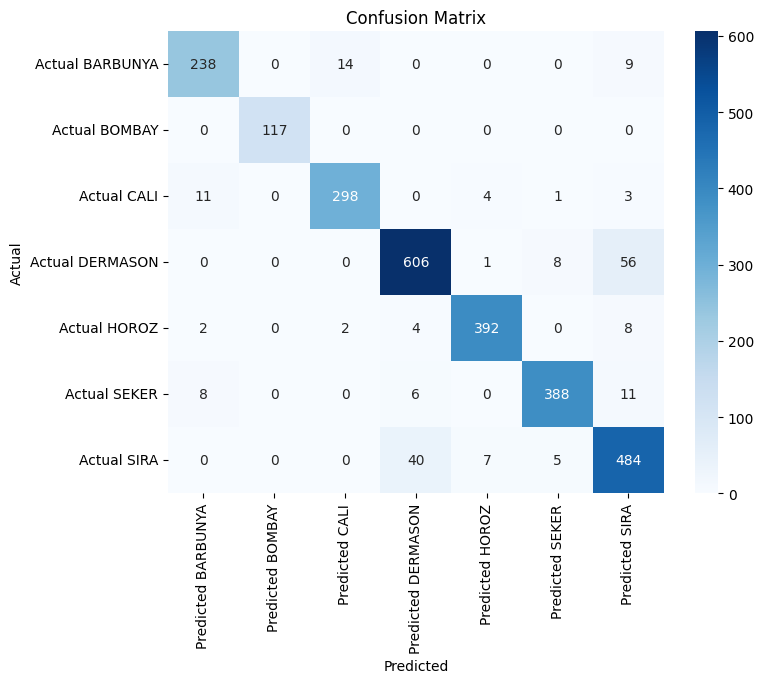

Saved results to results/model_results_bean.xlsx


In [18]:
fc.predict_multiclass_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original",
    epsilon=0,
    output_file="results/model_results_bean.xlsx"
)


In [19]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = False)

Accuracy: 0.9239
Precision: 0.9245
Recall: 0.9239
F1 Score: 0.9240
Prediction time:  4.227809906005859


{'fit_time': array([0.31130457, 0.82663274, 0.36500788, 0.43115711, 0.30884218,
        0.34715486, 0.40376902, 0.25522232, 0.28258991, 0.39826894]),
 'score_time': array([0.03607488, 0.02673507, 0.02564645, 0.0218668 , 0.02152681,
        0.04567409, 0.02534986, 0.02025962, 0.02952576, 0.02128887]),
 'test_accuracy': array([0.9164371 , 0.92929293, 0.92470156, 0.93204775, 0.91460055,
        0.92194674, 0.92837466, 0.92194674, 0.92095588, 0.92830882]),
 'test_precision': array([0.91783883, 0.93084033, 0.92544021, 0.93208038, 0.91453862,
        0.92208038, 0.92846311, 0.9223469 , 0.92313605, 0.92851079]),
 'test_recall': array([0.9164371 , 0.92929293, 0.92470156, 0.93204775, 0.91460055,
        0.92194674, 0.92837466, 0.92194674, 0.92095588, 0.92830882]),
 'test_f1': array([0.91681409, 0.92972706, 0.92492631, 0.93189716, 0.91421738,
        0.92191482, 0.92836906, 0.92196367, 0.92144307, 0.9282756 ])}

In [20]:
best_model, best_params = fc.hyperparameterTuning_save_Results(
    X_train_sc, 
    y_train, 
    cv=10, bivariate = False, 
    perturbation_type="Original_hpt",
    epsilon=0,
    output_file="results/model_results_bean.xlsx")

Best parameters: {'C': 100}
Accuracy : 0.9244
Precision: 0.9252
Recall   : 0.9244
F1 Score : 0.9246
Time     : 6.65 s


In [21]:
X_all = pd.concat([X_train, X_test], axis=0)
orig_confidence_scores = model.predict_proba(X_all)

with open("orig_confidence_scores_bean.pkl", "wb") as f:
    pickle.dump(orig_confidence_scores, f)

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [22]:
ranges = [[10000, 300000], [500, 2000], [100, 750], [100, 750],
       [1,3], [0,1], [10000, 300000], [100, 700], [0,1],
       [0,1], [0.2,1], [0.5,1], [0, 0.2], [0, 0.1],
       [0.2,1], [0.9, 1]]
print(ranges)

sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)

[[10000, 300000], [500, 2000], [100, 750], [100, 750], [1, 3], [0, 1], [10000, 300000], [100, 700], [0, 1], [0, 1], [0.2, 1], [0.5, 1], [0, 0.2], [0, 0.1], [0.2, 1], [0.9, 1]]
[290000, 1500, 650, 650, 2, 1, 290000, 600, 1, 1, 0.8, 0.5, 0.2, 0.1, 0.8, 0.09999999999999998]


In [23]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train.columns):
        eps_j = e # The paper uses eps_j = e/d, but this leades to huge errors
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train))

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [25]:
input_confidence_scores = {}

for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_multiclass(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_multiclass_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input",
        epsilon=e,
        output_file="results/model_results_bean.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = False, perturbation_type="Input_hpt",
        epsilon=e, output_file="results/model_results_bean.xlsx")

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    input_confidence_scores[e] = input_model.predict_proba(X_all)

with open("input_confidence_scores_bean.pkl", "wb") as f:
    pickle.dump(input_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy:  0.2639
Precision: 0.6128
Recall:    0.2639
F1 Score:  0.1103
---------------------------------------
---------------------------------------
Accuracy:  0.2464
Precision: 0.8143
Recall:    0.2464
F1 Score:  0.0974
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 0.1}
Accuracy : 0.2641
Precision: 0.6852
Recall   : 0.2641
F1 Score : 0.1109
Time     : 0.87 s
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.2686
Precision: 0.2350
Recall:    0.2686
F1 Score:  0.1632
---------------------------------------
---------------------------------------
Accuracy:  0.2475
Precision: 0.8144
Recall:    0.2475
F1 Score:  0.0997
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 1}
Accuracy : 0.2639
Precision: 0.2426
Recall   : 0.2639
F1 Score : 0.1598
Time     : 0.98 s
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.4601
Precision: 0.4355
Recall:    0.4601
F1 Score:  0.4381
---------------------------------------
---------------------------------------
Accuracy:  0.5876
Precision: 0.6343
Recall:    0.5876
F1 Score:  0.5454
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 1}
Accuracy : 0.4576
Precision: 0.4331
Recall   : 0.4576
F1 Score : 0.4352
Time     : 1.47 s


...

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Training set: 
---------------------------------------
Accuracy:  0.8940
Precision: 0.8945
Recall:    0.8940
F1 Score:  0.8942
---------------------------------------
---------------------------------------
Accuracy:  0.9236
Precision: 0.9248
Recall:    0.9236
F1 Score:  0.9239
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 10}
Accuracy : 0.8924
Precision: 0.8931
Recall   : 0.8924
F1 Score : 0.8925
Time     : 3.59 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Training set: 
---------------------------------------
Accuracy:  0.9142
Precision: 0.9147
Recall:    0.9142
F1 Score:  0.9144
---------------------------------------
---------------------------------------
Accuracy:  0.9254
Precision: 0.9263
Recall:    0.9254
F1 Score:  0.9257
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 1}
Accuracy : 0.9130
Precision: 0.9137
Recall   : 0.9130
F1 Score : 0.9131
Time     : 3.57 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [26]:
n = X_train.shape[0]
#C_x = np.max(np.linalg.norm(X_train, axis=1))
lambda_reg = 1 / model.C
sensitivity = (2) / (lambda_reg * n)

epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity / e,size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity / 3,size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [27]:
output_confidence_scores = {}

for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_multiclass(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_multiclass_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output",
        epsilon=e,
        output_file="results/model_results_bean.xlsx"
    )

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    output_confidence_scores[e] = output_model.predict_proba(X_all)

with open("output_confidence_scores_bean.pkl", "wb") as f:
    pickle.dump(output_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy:  0.9244
Precision: 0.9248
Recall:    0.9244
F1 Score:  0.9245
---------------------------------------
---------------------------------------
Accuracy:  0.9266
Precision: 0.9278
Recall:    0.9266
F1 Score:  0.9269
---------------------------------------
Saved results to results/model_results_bean.xlsx
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9245
Precision: 0.9249
Recall:    0.9245
F1 Score:  0.9246
---------------------------------------
---------------------------------------
Accuracy:  0.9266
Precision: 0.9278
Recall:    0.9266
F1 Score:  0.9269
---------------------------------------
Saved results to results/model_results_bean.xlsx
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9245
Precision: 0.9249
Recall:    0.9245
F1 Score:  0.9246
---------------------------------------
---------------------------------------
Accuracy:  0.9266
Precision: 0.9278
Recall:    0.9266
F1 Score:  0.9269
---------------------------------------
Saved results to results/model_results_bean.xlsx
Training set: 


...

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9245
Precision: 0.9249
Recall:    0.9245
F1 Score:  0.9246
---------------------------------------
---------------------------------------
Accuracy:  0.9266
Precision: 0.9278
Recall:    0.9266
F1 Score:  0.9269
---------------------------------------
Saved results to results/model_results_bean.xlsx
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9245
Precision: 0.9249
Recall:    0.9245
F1 Score:  0.9246
---------------------------------------
---------------------------------------
Accuracy:  0.9266
Precision: 0.9278
Recall:    0.9266
F1 Score:  0.9269
---------------------------------------
Saved results to results/model_results_bean.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [28]:

data_norm = np.max(np.linalg.norm(X_train_sc, axis=1))
print("data_norm (max L2 norm of a scaled training row):", data_norm)


data_norm (max L2 norm of a scaled training row): 18.688944706963216


In [ ]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]


internal_models = fc.internal_perturbation_save_results(
    "bean",
    X_train_sc,
    y_train,
    X_test_sc,
    y_test,
    epsilon_values=epsilon_values,
    data_norm=data_norm,
    C=model.C,
    bivariate=False,
    output_file="results/model_results_bean.xlsx",
    perturbation_type="Internal"
)




---------------------------------------
Epsilon: 0.1
Accuracy: 0.0896
Precision: 0.0728
Recall: 0.0896
F1 Score: 0.0744
Time: 0.15 s
---------------------------------------
---------------------------------------
Epsilon: 1
Accuracy: 0.3371
Precision: 0.2567
Recall: 0.3371
F1 Score: 0.2840
Time: 0.15 s
---------------------------------------
---------------------------------------
Epsilon: 5
Accuracy: 0.6974
Precision: 0.7012
Recall: 0.6974
F1 Score: 0.6946
Time: 0.25 s
---------------------------------------
---------------------------------------
Epsilon: 10
Accuracy: 0.8057
Precision: 0.8161
Recall: 0.8057
F1 Score: 0.8083
Time: 0.29 s
---------------------------------------
---------------------------------------
Epsilon: 30
Accuracy: 0.7958
Precision: 0.8426
Recall: 0.7958
F1 Score: 0.8041
Time: 0.42 s
---------------------------------------
---------------------------------------
Epsilon: 50
Accuracy: 0.9045
Precision: 0.9077
Recall: 0.9045
F1 Score: 0.9055
Time: 0.43 s
---------